In [1]:
!pip freeze
!python --version

absl-py==2.4.0
albucore==0.0.24
albumentations==2.0.8
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens @ file:///home/conda/feedstock_root/build_artifacts/asttokens_1763409923949/work
async-lru==2.1.0
attrs==25.4.0
babel==2.18.0
beautifulsoup4==4.14.3
black==26.1.0
bleach==6.3.0
certifi==2026.1.4
cffi==2.0.0
charset-normalizer==3.4.4
cjm-pandas-utils==0.0.3
cjm-pil-utils==0.0.9
cjm-psl-utils==0.0.4
cjm-pytorch-utils==0.0.8
cjm-torchvision-tfms==0.0.26
click==8.3.1
cloudpickle==3.1.2
comm @ file:///home/conda/feedstock_root/build_artifacts/bld/rattler-build_comm_1753453984/work
contourpy==1.3.3
cuda-bindings==12.9.4
cuda-pathfinder==1.3.4
cycler==0.12.1
debugpy @ file:///home/conda/feedstock_root/build_artifacts/bld/rattler-build_debugpy_1769744978/work
decorator @ file:///home/conda/feedstock_root/build_artifacts/decorator_1740384970518/work
defusedxml==0.7.1
detectron2 @ git+

In [2]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [3]:
import datetime
import os

import numpy as np
from torch.utils.data import Subset, DataLoader

from leaf_seg.dataset.plantdreamer_instance import build_dataset
from leaf_seg.instance.build import build_reporter
from leaf_seg.instance.train import fit, run
from leaf_seg.instance.finetune import finetune, load_pretrained_weights
from leaf_seg.common.config import InstanceTrainConfig, SemanticFinetuneConfig

In [4]:
def make_fixed_subset(dataset, fraction=None, n=None, seed=0):
    assert (fraction is None) ^ (n is None), "Specify exactly one of fraction or n"
    rng = np.random.default_rng(seed)

    N = len(dataset)
    k = int(round(N * fraction)) if fraction is not None else int(n)
    k = max(1, min(N, k))

    idx = rng.permutation(N)[:k].tolist()
    return Subset(dataset, idx)

In [5]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [38]:
XIMG = f"No of Synthetic Images"
XEPOCH = f"Epoch"

In [6]:
ROOT = Path("checkpoints/instance/train/[20260310-215722]_maskrcnn_trains")
MONITOR_COL = "val/segm_AP"          # primary metric
CONVERGENCE_RATIO = 0.95             # epoch to reach 95% of best monitor metric
PLATEAU_EPS = 0.002                  # plateau improvement threshold (AP)
PLATEAU_PATIENCE = 10                # plateau patience in epochs
STABILITY_WINDOW = 10                # last-K epochs window for stability stats
THRESHOLDS = [0.10, 0.20, 0.30]       # AP thresholds for time-to-threshold plots (adjust to your regime)

_subset_re = re.compile(r"\[subset-(?P<n>\d+)\]")

def extract_real_count(run_name: str) -> int:
    m = _subset_re.search(run_name)
    if not m:
        raise ValueError(f"Could not parse subset size from: {run_name}")
    return int(m.group("n"))

def _as_numeric(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        if c != "epoch":
            out[c] = pd.to_numeric(out[c], errors="coerce")
    out["epoch"] = pd.to_numeric(out["epoch"], errors="coerce")
    return out

def add_cum_time(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "time/epoch" in out.columns and out["time/epoch"].notna().any():
        out["cum_time_sec"] = out["time/epoch"].fillna(0).cumsum()
    else:
        tr = out["time/train"].fillna(0) if "time/train" in out.columns else 0
        va = out["time/val"].fillna(0) if "time/val" in out.columns else 0
        out["cum_time_sec"] = (tr + va).cumsum()
    out["cum_time_hr"] = out["cum_time_sec"] / 3600.0
    return out

def first_crossing(df: pd.DataFrame, col: str, thr: float) -> tuple[int | None, float | None]:
    """Return (epoch, cum_time_sec) of first crossing col >= thr."""
    s = df[col]
    hit = df.index[s >= thr]
    if len(hit) == 0:
        return None, None
    i = hit[0]
    return int(df.loc[i, "epoch"]), float(df.loc[i, "cum_time_sec"])

def plateau_epoch(df: pd.DataFrame, col: str, eps: float, patience: int) -> int | None:
    """Earliest epoch after which improvement < eps over next patience epochs."""
    vals = df[col].to_numpy(dtype=float)
    if np.all(np.isnan(vals)):
        return None
    N = len(vals)
    for i in range(N - patience):
        cur = np.nanmax(vals[: i + 1])
        fut = np.nanmax(vals[i + 1 : i + 1 + patience])
        if not np.isfinite(cur) or not np.isfinite(fut):
            continue
        if fut - cur < eps:
            return int(df.loc[i, "epoch"])
    return None


In [7]:
summary_rows = []
full_rows = []

for run_dir in sorted([p for p in ROOT.iterdir() if p.is_dir()]):
    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        continue

    df = pd.read_csv(csv_path)
    df = _as_numeric(df)
    df = add_cum_time(df)

    # Skip if monitor column missing or all NaN
    if MONITOR_COL not in df.columns or df[MONITOR_COL].notna().sum() == 0:
        continue

    real_count = extract_real_count(run_dir.name)

    # Best epoch by monitor
    best_idx = df[MONITOR_COL].idxmax()
    best_row = df.loc[best_idx]
    best_epoch = int(best_row["epoch"])
    best_time_sec = float(best_row["cum_time_sec"])
    best_value = float(best_row[MONITOR_COL])

    # Convergence epoch to 95% of best
    conv_thr = CONVERGENCE_RATIO * best_value
    conv_hits = df[df[MONITOR_COL] >= conv_thr]
    conv_epoch = int(conv_hits["epoch"].iloc[0]) if len(conv_hits) else None
    conv_time_sec = float(conv_hits["cum_time_sec"].iloc[0]) if len(conv_hits) else None

    # Precision/alignment gaps at best epoch
    segm_gap = None
    if "val/segm_AP50" in df.columns and "val/segm_AP75" in df.columns:
        if pd.notna(best_row["val/segm_AP50"]) and pd.notna(best_row["val/segm_AP75"]):
            segm_gap = float(best_row["val/segm_AP50"] - best_row["val/segm_AP75"])

    bbox_gap = None
    if "val/bbox_AP50" in df.columns and "val/bbox_AP75" in df.columns:
        if pd.notna(best_row["val/bbox_AP50"]) and pd.notna(best_row["val/bbox_AP75"]):
            bbox_gap = float(best_row["val/bbox_AP50"] - best_row["val/bbox_AP75"])

    # Stability over last K epochs (monitor)
    tail = df[MONITOR_COL].tail(STABILITY_WINDOW)
    stability_std = float(tail.std()) if tail.notna().sum() >= 2 else None
    stability_mad = float(tail.diff().abs().mean()) if tail.notna().sum() >= 2 else None

    # Plateau epoch (heuristic)
    plat_epoch = plateau_epoch(df, MONITOR_COL, eps=PLATEAU_EPS, patience=PLATEAU_PATIENCE)

    # Time-to-thresholds
    tt = {}
    for t in THRESHOLDS:
        e, ts = first_crossing(df, MONITOR_COL, t)
        tt[f"epoch_to_AP{int(t*100):02d}"] = e
        tt[f"time_to_AP{int(t*100):02d}_sec"] = ts

    # Total training time
    total_time_sec = float(df["time/epoch"].sum()) if "time/epoch" in df.columns else float(df["cum_time_sec"].iloc[-1])

    summary_rows.append({
        "run": run_dir.name,
        "real_count": real_count,
        "best_epoch": best_epoch,
        "best_time_sec": best_time_sec,
        "best_time_hr": best_time_sec / 3600.0,
        "best_segm_AP": float(best_row.get("val/segm_AP")) if "val/segm_AP" in df.columns else None,
        "best_segm_AP50": float(best_row.get("val/segm_AP50")) if "val/segm_AP50" in df.columns else None,
        "best_segm_AP75": float(best_row.get("val/segm_AP75")) if "val/segm_AP75" in df.columns else None,
        "best_segm_APs": float(best_row.get("val/segm_APs")) if "val/segm_APs" in df.columns else None,
        "best_segm_APm": float(best_row.get("val/segm_APm")) if "val/segm_APm" in df.columns else None,
        "best_segm_APl": float(best_row.get("val/segm_APl")) if "val/segm_APl" in df.columns else None,
        "best_bbox_AP": float(best_row.get("val/bbox_AP")) if "val/bbox_AP" in df.columns else None,
        "best_bbox_AP50": float(best_row.get("val/bbox_AP50")) if "val/bbox_AP50" in df.columns else None,
        "best_bbox_AP75": float(best_row.get("val/bbox_AP75")) if "val/bbox_AP75" in df.columns else None,
        "segm_AP50_AP75_gap": segm_gap,
        "bbox_AP50_AP75_gap": bbox_gap,
        "convergence_epoch_95pct": conv_epoch,
        "convergence_time_95pct_sec": conv_time_sec,
        "plateau_epoch": plat_epoch,
        "stability_last10_std": stability_std,
        "stability_last10_mad": stability_mad,
        "total_training_time_sec": total_time_sec,
        "total_training_time_hr": total_time_sec / 3600.0,
        **tt,
    })

    # keep full series for overlay plots
    tmp = df.copy()
    tmp["run"] = run_dir.name
    tmp["real_count"] = real_count
    full_rows.append(tmp)

summary = pd.DataFrame(summary_rows).sort_values("real_count").reset_index(drop=True)
full = pd.concat(full_rows, ignore_index=True).sort_values(["real_count", "epoch"]).reset_index(drop=True)

summary["delta_best_segm_AP"] = summary["best_segm_AP"].diff()


In [8]:
summary

,run,real_count,best_epoch,best_time_sec,best_time_hr,best_segm_AP,best_segm_AP50,best_segm_AP75,best_segm_APs,best_segm_APm,...,stability_last10_mad,total_training_time_sec,total_training_time_hr,epoch_to_AP10,time_to_AP10_sec,epoch_to_AP20,time_to_AP20_sec,epoch_to_AP30,time_to_AP30_sec,delta_best_segm_AP
0,train[subset-100]-maskrcnn-bean_sdxl_inst,100,2,118.097680,0.032805,0.142812,0.257970,0.141433,0.037677,0.108344,...,0.000087,3287.773947,0.913271,1,62.965696,None,None,None,None,NaN
1,train[subset-200]-maskrcnn-bean_sdxl_inst,200,2,118.760896,0.032989,0.134346,0.234048,0.133861,0.038844,0.105342,...,0.000069,3705.251022,1.029236,1,62.416489,None,None,None,None,-0.008466
2,train[subset-300]-maskrcnn-bean_sdxl_inst,300,1,65.976001,0.018327,0.131666,0.228632,0.141122,0.041784,0.116377,...,0.000061,4365.943899,1.212762,1,65.976001,None,None,None,None,-0.002680
3,train[subset-400]-maskrcnn-bean_sdxl_inst,400,1,76.413457,0.021226,0.161034,0.259357,0.169121,0.040579,0.114255,...,0.000060,5122.561568,1.422934,1,76.413457,None,None,None,None,0.029368
4,train[subset-500]-maskrcnn-bean_sdxl_inst,500,14,938.919295,0.260811,0.134129,0.231571,0.135813,0.024395,0.131776,...,0.000242,5907.924921,1.641090,1,81.568383,None,None,None,None,-0.026905
5,train[subset-600]-maskrcnn-bean_sdxl_inst,600,1,89.271491,0.024798,0.125883,0.213251,0.130230,0.038562,0.111498,...,0.000094,6515.832185,1.809953,1,89.271491,None,None,None,None,-0.008246
6,train[subset-700]-maskrcnn-bean_sdxl_inst,700,3,263.127431,0.073091,0.125059,0.223170,0.123779,0.030359,0.106020,...,0.000131,7265.212534,2.018115,1,91.797420,None,None,None,None,-0.000824
7,train[subset-800]-maskrcnn-bean_sdxl_inst,800,1,98.633295,0.027398,0.120124,0.217391,0.114512,0.037785,0.111630,...,0.000256,7987.615505,2.218782,1,98.633295,None,None,None,None,-0.004935
8,train[subset-900]-maskrcnn-bean_sdxl_inst,900,2,212.592525,0.059053,0.138708,0.242455,0.134527,0.033743,0.113839,...,0.000055,9028.227090,2.507841,1,110.506943,None,None,None,None,0.018584
9,train[subset-1000]-maskrcnn-bean_sdxl_inst,1000,4,451.381721,0.125384,0.136878,0.235139,0.141870,0.024850,0.108029,...,0.000084,8174.793630,2.270776,1,118.407144,None,None,None,None,-0.001830


In [9]:
%matplotlib inline

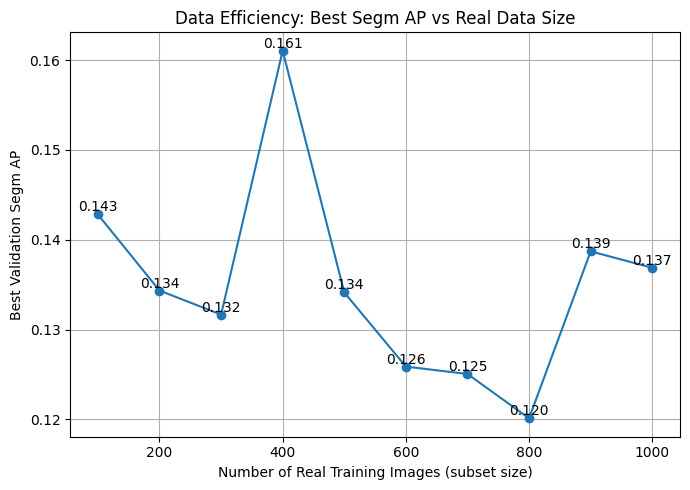

In [23]:
# 1) Data efficiency: best segm AP vs real_count (log-x often useful)
x = summary["real_count"]
y = summary["best_segm_AP"]

plt.figure(figsize=(7,5))
plt.plot(x, y, marker="o")


for xi, yi in zip(x, y):
    plt.text(xi, yi, f'{yi:.3f}',
             ha='center',
             va='bottom')
    
plt.xlabel("Number of Real Training Images (subset size)")
# plt.xticks(np.arange(0, 110, step=10))
plt.ylabel("Best Validation Segm AP")
plt.title("Data Efficiency: Best Segm AP vs Real Data Size")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()



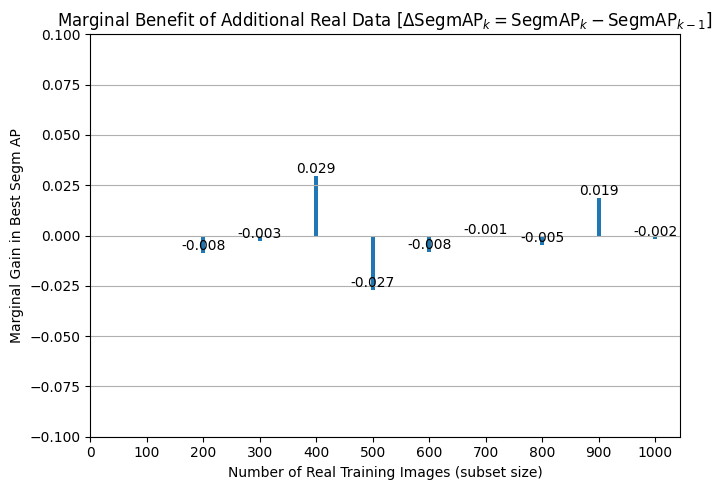

In [31]:
# 2) Marginal gains: delta best AP as you add more real data


plt.figure(figsize=(7,5))
bars = plt.bar(summary["real_count"][1:], summary["delta_best_segm_AP"][1:], width=7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.3f}', ha='center',va='bottom')
plt.xlabel("Number of Real Training Images (subset size)")
plt.xticks(np.arange(0, 1001, step=100))
plt.ylabel("Marginal Gain in Best Segm AP")
plt.ylim(-0.1, 0.1)
plt.title(r"Marginal Benefit of Additional Real Data [$\Delta \text{SegmAP}_k = \text{SegmAP}_k - \text{SegmAP}_{k-1}$]")
plt.tight_layout()
plt.grid(True, axis="y")
plt.show()

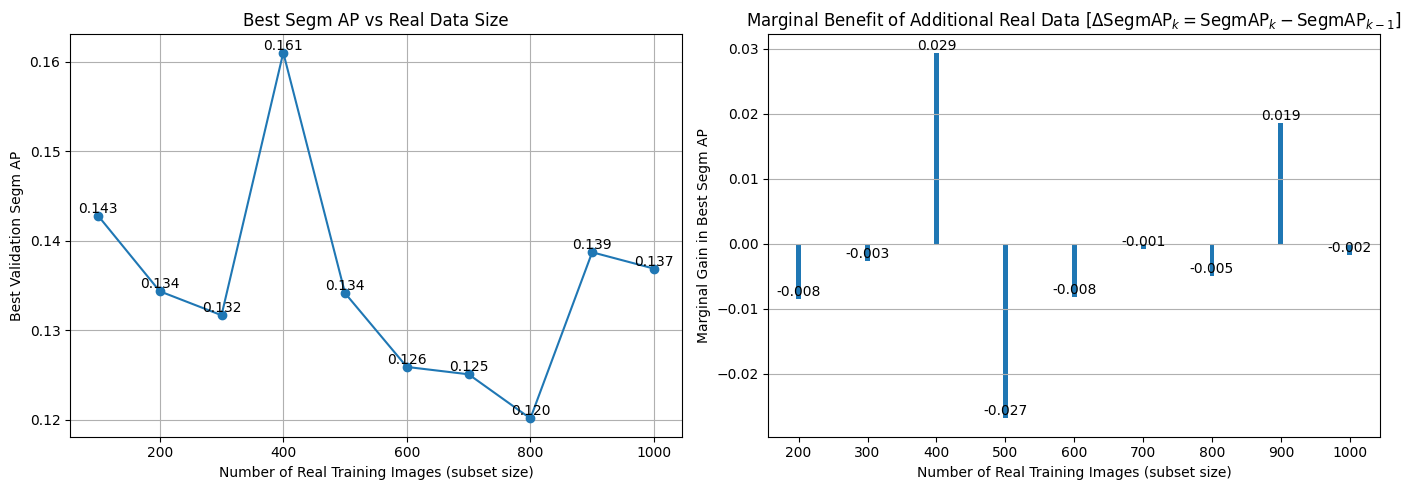

In [32]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Best Segm AP vs Real Data Size ---
x = summary["real_count"]
y = summary["best_segm_AP"]

ax1.plot(x, y, marker="o")
for xi, yi in zip(x, y):
    ax1.text(xi, yi, f"{yi:.3f}", ha="center", va="bottom")

ax1.set_xlabel("Number of Real Training Images (subset size)")
ax1.set_ylabel("Best Validation Segm AP")
ax1.set_title("Best Segm AP vs Real Data Size")
# ax1.set_xticks(np.arange(0, 110, step=10))
ax1.grid(True, which="both")

# --- Right plot: Marginal Gain in Best Segm AP ---
bars = ax2.bar(summary["real_count"][1:], summary["delta_best_segm_AP"][1:], width=7)

for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

ax2.set_xlabel("Number of Real Training Images (subset size)")
ax2.set_ylabel("Marginal Gain in Best Segm AP")
ax2.set_title(
    r"Marginal Benefit of Additional Real Data "
    r"[$\Delta \mathrm{SegmAP}_k = \mathrm{SegmAP}_k - \mathrm{SegmAP}_{k-1}$]"
)
# ax2.set_xticks(np.arange(0, 110, step=10))
ax2.grid(True, axis="y", which="both")

plt.tight_layout()
plt.show()

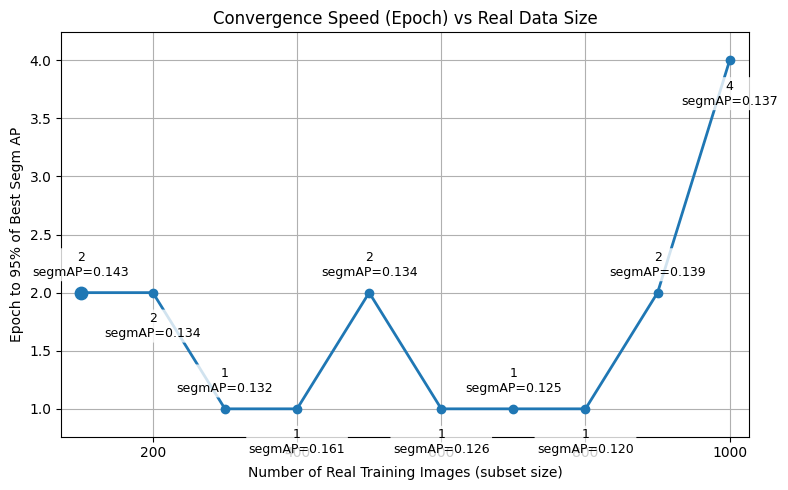

In [34]:
# 3) Convergence speed: epoch to reach 95% of best AP
# x = summary["real_count"]
# y = summary["convergence_epoch_95pct"]

# plt.figure(figsize=(7,5))
# plt.plot(x, y, marker="o")

# for xi, yi in zip(x, y):
#     plt.text(xi, yi, f'{yi}',
#              ha='center',
#              va='bottom')

# plt.xlabel("Number of Real Training Images (subset size)")
# plt.xticks(np.arange(0, 110, step=10))
# plt.ylabel("Epoch to 95% of Best Segm AP")
# plt.title("Convergence Speed (Epoch) vs Real Data Size")
# plt.grid(True, which="both")
# plt.tight_layout()
# plt.show()


x = summary["real_count"].to_numpy()
y = summary["convergence_epoch_95pct"].astype(np.uint).to_numpy()
segmAP = summary["best_segm_AP"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))

# Main line
ax.plot(x, y, marker="o", linewidth=2, markersize=6)

# Optional: highlight the baseline (x=0) point
if len(x) > 0:
    ax.scatter([x[0]], [y[0]], s=80, zorder=3)

# Annotate points with alternating offsets to reduce overlap
for i, (xi, yi, m) in enumerate(zip(x, y, segmAP)):
    # Alternate annotation positions (up/down) for readability
    dy = 10 if i % 2 == 0 else -14
    va = "bottom" if dy > 0 else "top"
    
    ax.annotate(
        f"{int(yi)}\nsegmAP={m:.3f}",
        (xi, yi),
        xytext=(0, dy),
        textcoords="offset points",
        ha="center",
        va=va,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
    )

# Axes formatting
plt.xlabel("Number of Real Training Images (subset size)")
# plt.xticks(np.arange(0, 110, step=10))
plt.ylabel("Epoch to 95% of Best Segm AP")
plt.title("Convergence Speed (Epoch) vs Real Data Size")
# ax.set_xticks(np.arange(0, max(x) + 10, 10))
ax.grid(True) #  linestyle="--", alpha=0.35

# Add a little padding around data limits
ax.margins(x=0.03, y=0.08)

plt.tight_layout()
plt.show()

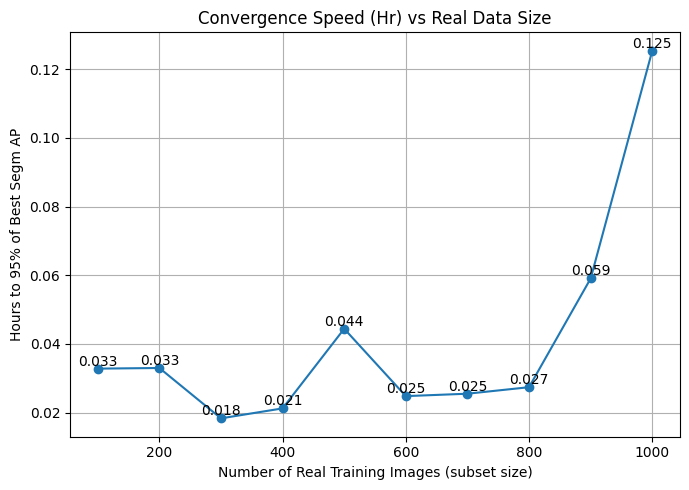

In [14]:
# 4) Convergence speed in wall-clock time (if you care about compute efficiency)
plt.figure(figsize=(7,5))
x = summary["real_count"]
y = summary["convergence_time_95pct_sec"]/3600.0
plt.plot(x, y, marker="o")
for xi, yi in zip(x, y):
    plt.text(xi, yi, f'{yi:.3f}',
             ha='center',
             va='bottom')
plt.xlabel("Number of Real Training Images (subset size)")
plt.ylabel("Hours to 95% of Best Segm AP")
plt.title("Convergence Speed (Hr) vs Real Data Size") # Compute-Normalised Convergence
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

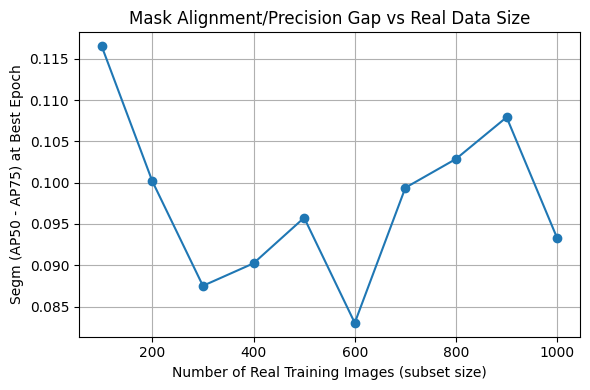

In [15]:
# 5) Precision/alignment gap: AP50 - AP75 (segm) vs real_count
plt.figure(figsize=(6,4))
plt.plot(summary["real_count"], summary["segm_AP50_AP75_gap"], marker="o")
plt.xlabel("Number of Real Training Images (subset size)")
plt.ylabel("Segm (AP50 - AP75) at Best Epoch")
plt.title("Mask Alignment/Precision Gap vs Real Data Size")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

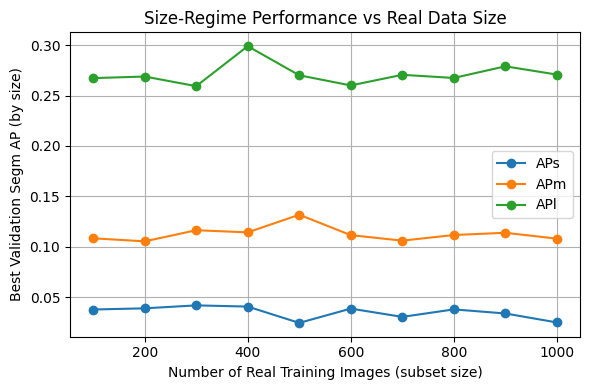

In [16]:
# 6) Size regime scaling: APs/APm/APl vs real_count (at best epoch)
plt.figure(figsize=(6,4))
plt.plot(summary["real_count"], summary["best_segm_APs"], marker="o", label="APs")
plt.plot(summary["real_count"], summary["best_segm_APm"], marker="o", label="APm")
plt.plot(summary["real_count"], summary["best_segm_APl"], marker="o", label="APl")
plt.xlabel("Number of Real Training Images (subset size)")
plt.ylabel("Best Validation Segm AP (by size)")
plt.title("Size-Regime Performance vs Real Data Size")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

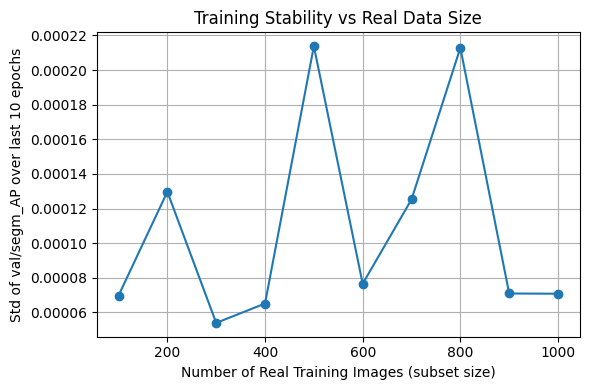

In [17]:
# 7) Stability/noise proxy: std of last K epochs vs real_count
plt.figure(figsize=(6,4))
plt.plot(summary["real_count"], summary["stability_last10_std"], marker="o")
plt.xlabel("Number of Real Training Images (subset size)")
plt.ylabel(f"Std of {MONITOR_COL} over last {STABILITY_WINDOW} epochs")
plt.title("Training Stability vs Real Data Size")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

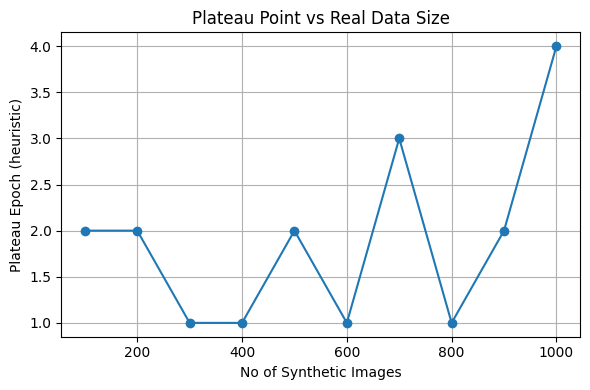

In [40]:
# 8) Plateau epoch (heuristic): when improvements effectively stop
plt.figure(figsize=(6,4))
plt.plot(summary["real_count"], summary["plateau_epoch"], marker="o")
plt.xlabel(XIMG)
plt.ylabel("Plateau Epoch (heuristic)")
plt.title("Plateau Point vs Real Data Size")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


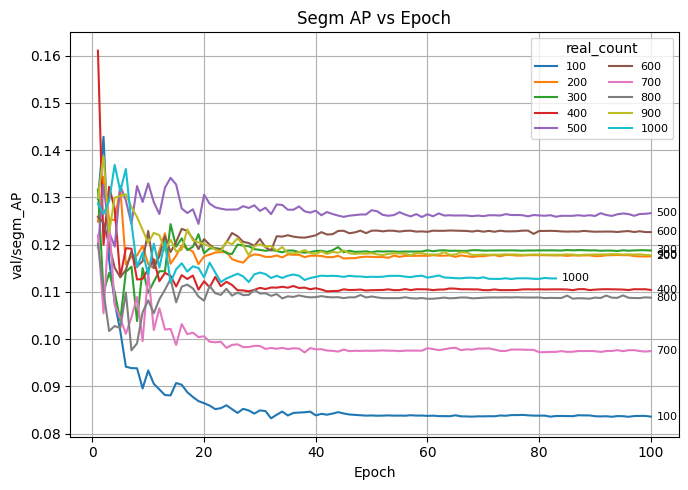

In [36]:
# 9) Overlay: segm AP vs epoch for all runs (convergence curves)
plt.figure(figsize=(7,5))

groups = list(full.groupby("real_count"))
colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))

for (color, (rc, g)) in zip(colors, groups):
    g = g.sort_values("epoch")
    plt.plot(g["epoch"], g[MONITOR_COL], label=str(rc))

    # label at the end of each line
    x_last = g["epoch"].iloc[-1]
    y_last = g[MONITOR_COL].iloc[-1]
    plt.text(x_last + 1, y_last, str(rc), fontsize=8, va="center")

plt.xlabel("Epoch")
plt.ylabel(MONITOR_COL)
plt.title("Segm AP vs Epoch")
plt.grid(True)
plt.legend(title="real_count", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


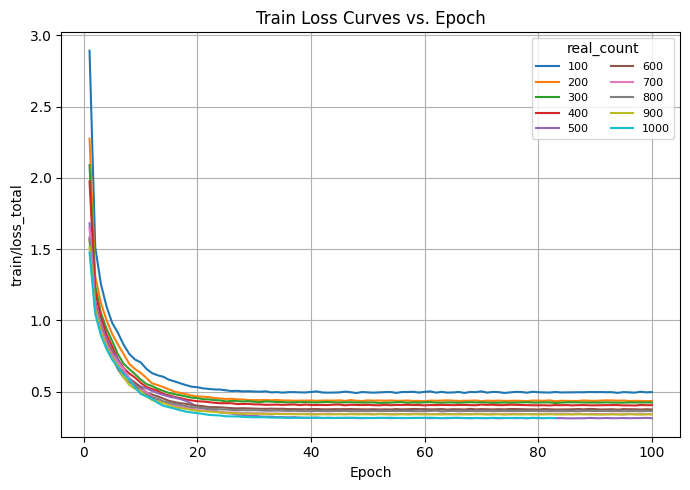

In [20]:
# 12) opt: training loss vs AP at best epoch (diagnostic, not a generalisation gap)
# (no val loss though we can still see if loss keeps dropping while AP saturates.)
if "train/loss_total" in full.columns:
    plt.figure(figsize=(7,5))
    for rc, g in full.groupby("real_count"):
        plt.plot(g["epoch"], g["train/loss_total"], label=str(rc))
    plt.xlabel("Epoch")
    plt.ylabel("train/loss_total")
    plt.title("Train Loss Curves vs. Epoch") # (context for AP behaviour)
    plt.grid(True)
    plt.legend(title="real_count", ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

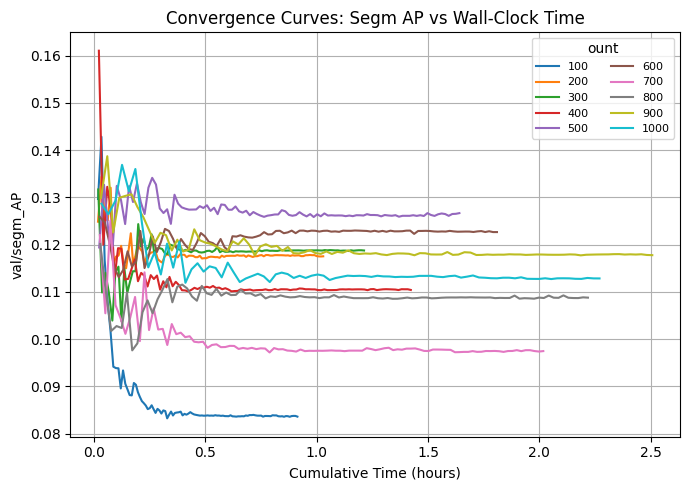

In [21]:
# 10) Overlay: segm AP vs cumulative wall-clock time (compute-normalised)
plt.figure(figsize=(7,5))
for rc, g in full.groupby("real_count"):
    plt.plot(g["cum_time_hr"], g[MONITOR_COL], label=str(rc))
plt.xlabel("Cumulative Time (hours)")
plt.ylabel(MONITOR_COL)
plt.title("Convergence Curves: Segm AP vs Wall-Clock Time")
plt.grid(True)
plt.legend(title="ount", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

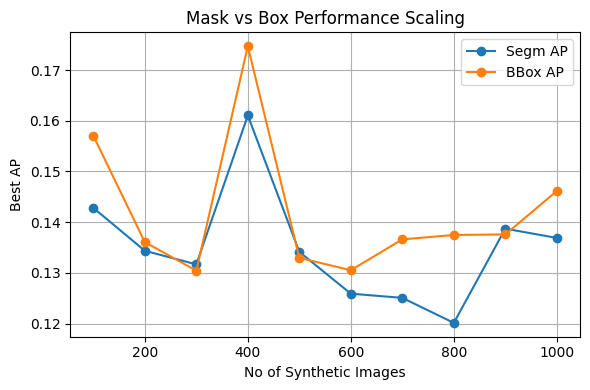

In [39]:
# 11) opt: compare masks vs boxes scaling directly (best epoch summaries)
plt.figure(figsize=(6,4))
plt.plot(summary["real_count"], summary["best_segm_AP"], marker="o", label="Segm AP")
plt.plot(summary["real_count"], summary["best_bbox_AP"], marker="o", label="BBox AP")
plt.xlabel(XIMG)
plt.ylabel("Best AP")
plt.title("Mask vs Box Performance Scaling")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()